# Sales and Discounts: Descriptive Statistics and Preprocessing

This project examines 450 sales records supplied with the ExcelR Basic Statistics assignment. It covers every requested numerical summary, histograms, boxplots, category counts, z-score scaling, and one-hot encoding. Monetary values are reported in the dataset's original units because no currency is specified.

The analysis preserves the original CSV. Potential outliers are flagged for review, not automatically deleted. This is exploratory analysis and preprocessing, not a predictive model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display

BASE = Path.cwd()
if BASE.name in ('notebooks', 'src'):
    BASE = BASE.parent
for folder in ('results', 'figures'):
    (BASE / folder).mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

## 1. Load and inspect the data
Dates are parsed as day-month-year. Date is a time variable, not a nominal category. SKU and Model remain categorical identifiers.

In [2]:
df = pd.read_csv(BASE / 'data/sales_data_with_discounts.csv')
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='raise')
numeric = df.select_dtypes(include='number').columns.tolist()
categorical = [c for c in df.columns if c not in numeric + ['Date']]
print(f'Shape: {df.shape}; date range: {df.Date.min().date()} to {df.Date.max().date()}')
print('Numeric columns:', numeric)
print('Categorical columns:', categorical)
display(df.head())
quality = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(),
                        'unique': df.nunique()})
display(quality)
print('Duplicate complete rows:', df.duplicated().sum())
print('Duplicate date/SKU combinations:', df.duplicated(['Date', 'SKU']).sum())
assert not df.isna().any().any(), 'Review missing values before preprocessing.'
assert (df['Day'] == df['Date'].dt.day_name()).all()
assert np.allclose(df['Total Sales Value'], df.Volume * df['Avg Price'])
assert np.allclose(df['Discount Amount'], df['Total Sales Value'] * df['Discount Rate (%)'] / 100)
assert np.allclose(df['Net Sales Value'], df['Total Sales Value'] - df['Discount Amount'])
print('All three sales arithmetic checks passed.')
quality.to_csv(BASE / 'results/data_quality.csv')

Shape: (450, 13); date range: 2021-04-01 to 2021-04-15
Numeric columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)', 'Discount Amount', 'Net Sales Value']
Categorical columns: ['Day', 'SKU', 'City', 'BU', 'Brand', 'Model']


,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2021-04-01,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,2021-04-01,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,2021-04-01,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,2021-04-01,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,2021-04-01,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


,dtype,missing,unique
Date,datetime64[us],0,15
Day,str,0,7
SKU,str,0,30
City,str,0,1
Volume,int64,0,22
BU,str,0,3
Brand,str,0,9
Model,str,0,30
Avg Price,int64,0,25
Total Sales Value,int64,0,135


Duplicate complete rows: 0
Duplicate date/SKU combinations: 0
All three sales arithmetic checks passed.


## 2. Descriptive statistics
The mean measures the arithmetic average, while the median is less sensitive to extreme observations. Standard deviation uses the **sample convention, ddof=1**. All tied modes are retained. A continuous column with every value unique has no informative mode, rather than a meaningful list of 450 modes.

In [3]:
summary = df[numeric].describe().T
summary['median'] = df[numeric].median()
summary['skewness'] = df[numeric].skew()
def modes_text(s):
    counts = s.value_counts()
    if counts.max() == 1:
        return 'No repeated value'
    return ', '.join(f'{v:g}' for v in sorted(counts[counts == counts.max()].index))
summary['mode'] = [modes_text(df[c]) for c in numeric]
display(summary[['mean', 'median', 'mode', 'std', 'min', '25%', '75%', 'max', 'skewness']])
summary.to_csv(BASE / 'results/descriptive_statistics.csv')
for c in numeric:
    r = summary.loc[c]
    print(f'{c}: mean={r["mean"]:.3f}, median={r["median"]:.3f}, '
          f'sample SD={r["std"]:.3f}, skewness={r["skewness"]:.3f}.')

,mean,median,mode,std,min,25%,75%,max,skewness
Volume,5.066667,4.000000,3,4.231602,1.000000,3.000000,6.000000,31.000000,2.731724
Avg Price,10453.433333,1450.000000,"400, 450, 500, 1300, 8100",18079.904840,290.000000,465.000000,10100.000000,60100.000000,1.908873
Total Sales Value,33812.835556,5700.000000,24300,50535.074173,400.000000,2700.000000,53200.000000,196400.000000,1.534729
Discount Rate (%),15.155242,16.577766,No repeated value,4.220602,5.007822,13.965063,18.114718,19.992407,-1.062294
Discount Amount,3346.499424,988.933733,No repeated value,4509.902963,69.177942,460.459304,5316.495427,25738.022194,1.913038
Net Sales Value,30466.336131,4677.788059,No repeated value,46358.656624,326.974801,2202.208645,47847.912852,179507.479049,1.540822


Volume: mean=5.067, median=4.000, sample SD=4.232, skewness=2.732.
Avg Price: mean=10453.433, median=1450.000, sample SD=18079.905, skewness=1.909.
Total Sales Value: mean=33812.836, median=5700.000, sample SD=50535.074, skewness=1.535.
Discount Rate (%): mean=15.155, median=16.578, sample SD=4.221, skewness=-1.062.
Discount Amount: mean=3346.499, median=988.934, sample SD=4509.903, skewness=1.913.
Net Sales Value: mean=30466.336, median=4677.788, sample SD=46358.657, skewness=1.541.


## 3. Histograms and boxplots
Separate axes prevent the different measurement scales from obscuring the distributions. Histogram bin choice affects the visual appearance. The boxplot uses the 1.5 × IQR rule: observations below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged. This rule identifies unusual values; it does not prove that they are errors.

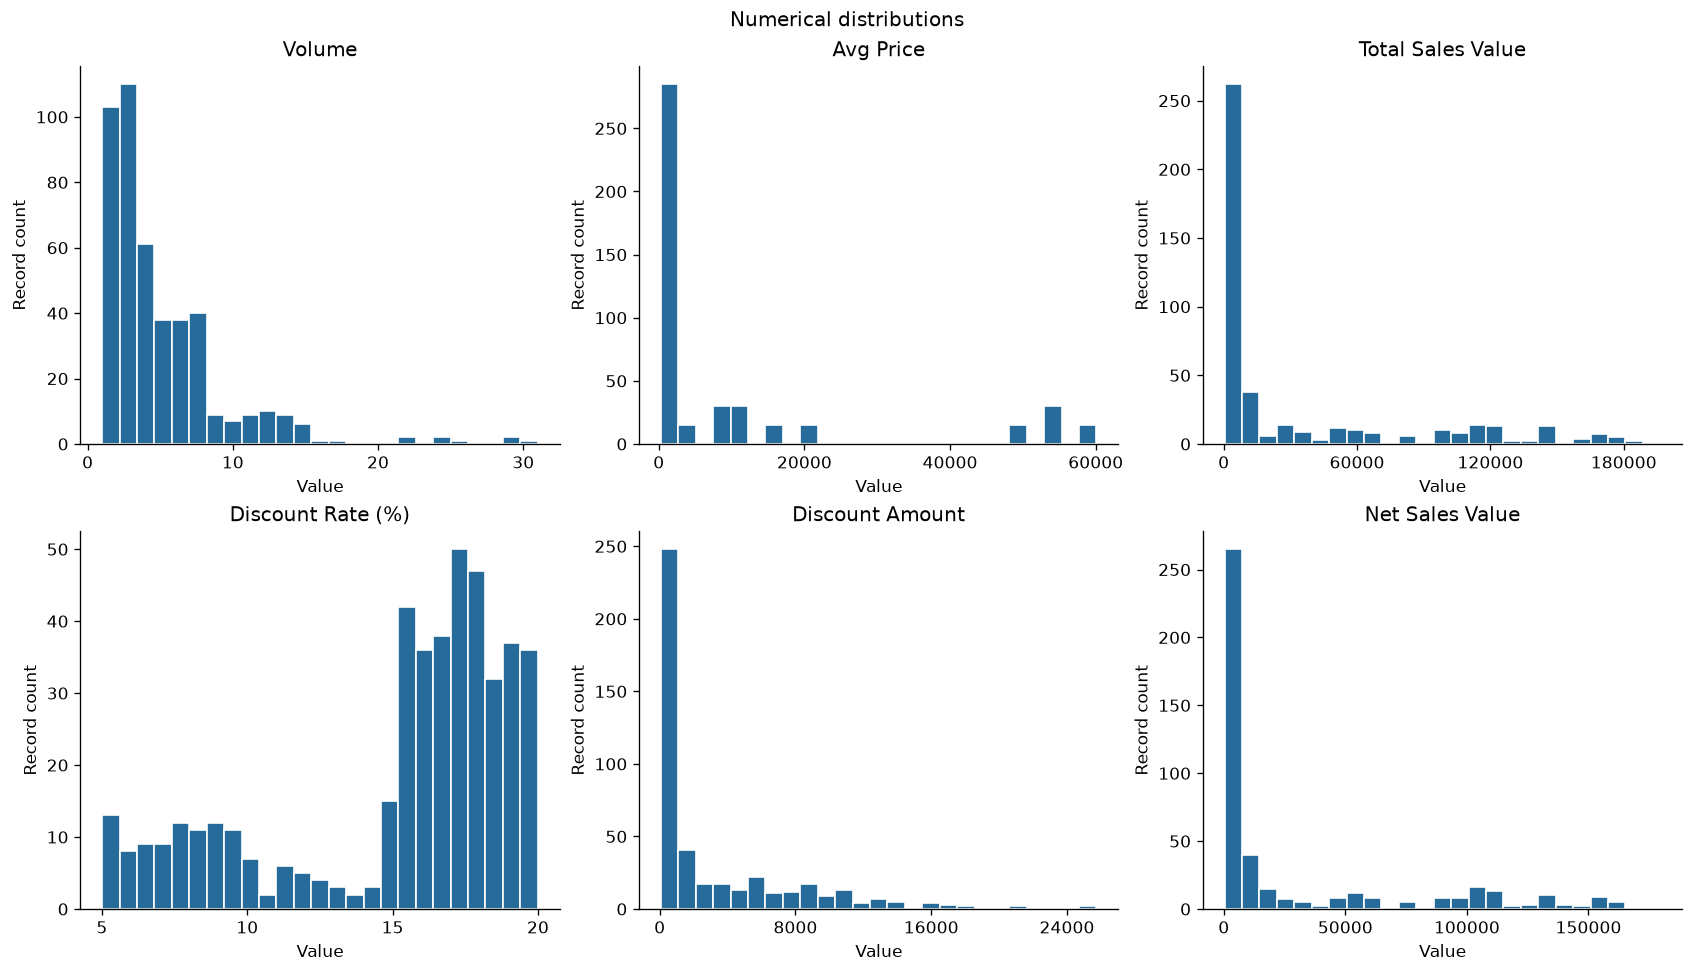

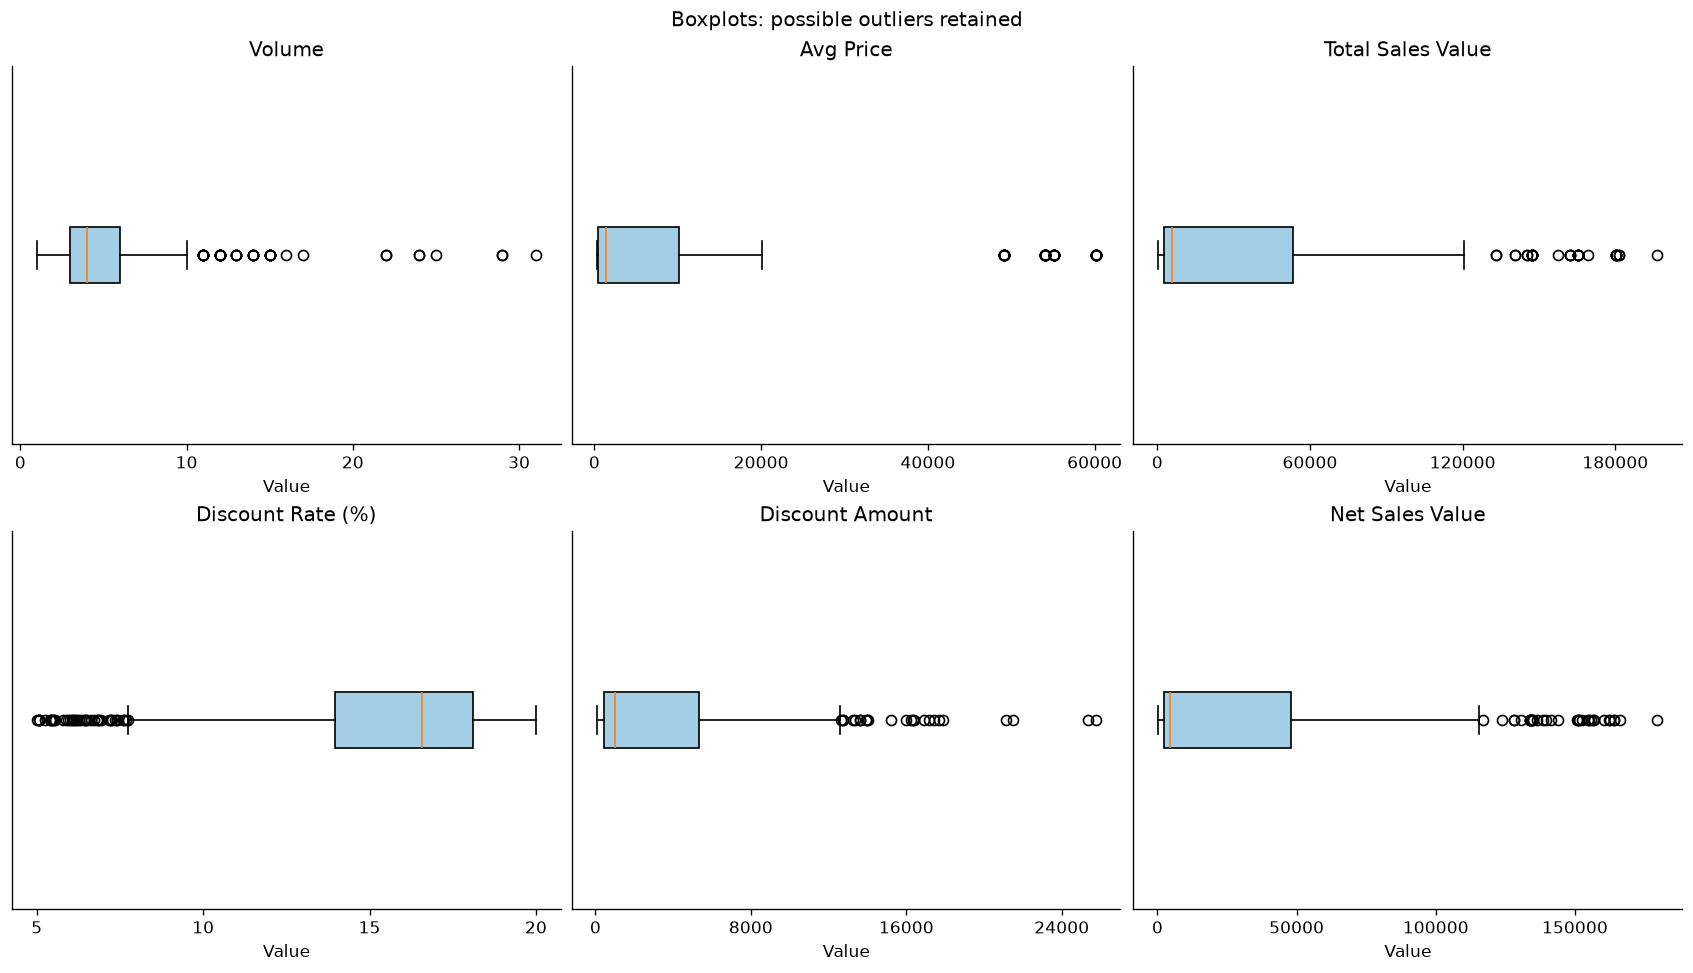

,variable,Q1,Q3,IQR,lower_fence,upper_fence,flagged_count
0,Volume,3.000000,6.000000,3.000000,-1.500000,10.500000,44
1,Avg Price,465.000000,10100.000000,9635.000000,-13987.500000,24552.500000,60
2,Total Sales Value,2700.000000,53200.000000,50500.000000,-73050.000000,128950.000000,36
3,Discount Rate (%),13.965063,18.114718,4.149656,7.740579,24.339202,45
4,Discount Amount,460.459304,5316.495427,4856.036123,-6823.594880,12600.549611,24
5,Net Sales Value,2202.208645,47847.912852,45645.704206,-66266.347664,116316.469161,35


Volume: IQR=3.000; 44 of 450 records outside the fences.
Avg Price: IQR=9635.000; 60 of 450 records outside the fences.
Total Sales Value: IQR=50500.000; 36 of 450 records outside the fences.
Discount Rate (%): IQR=4.150; 45 of 450 records outside the fences.
Discount Amount: IQR=4856.036; 24 of 450 records outside the fences.
Net Sales Value: IQR=45645.704; 35 of 450 records outside the fences.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for ax, c in zip(axes.flat, numeric):
    ax.hist(df[c], bins=25, color='#266b99', edgecolor='white')
    ax.set(title=c, xlabel='Value', ylabel='Record count')
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
fig.suptitle('Numerical distributions')
fig.savefig(BASE / 'figures/histograms.png')
plt.show()
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
outlier_rows = []
for ax, c in zip(axes.flat, numeric):
    ax.boxplot(df[c], orientation='horizontal', patch_artist=True,
               boxprops={'facecolor': '#a4cee5'})
    ax.set(title=c, xlabel='Value', yticks=[])
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    q1, q3 = df[c].quantile([.25, .75]); iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df[c] < lower) | (df[c] > upper)
    outlier_rows.append([c, q1, q3, iqr, lower, upper, int(mask.sum())])
fig.suptitle('Boxplots: possible outliers retained')
fig.savefig(BASE / 'figures/boxplots.png')
plt.show()
outliers = pd.DataFrame(outlier_rows, columns=['variable','Q1','Q3','IQR','lower_fence','upper_fence','flagged_count'])
display(outliers)
for row in outliers.itertuples(index=False):
    print(f'{row.variable}: IQR={row.IQR:.3f}; {row.flagged_count} of {len(df)} records outside the fences.')
outliers.to_csv(BASE / 'results/outlier_summary.csv', index=False)

### Interpretation
Volume, average price, total sales, discount amount, and net sales have positive skew: their means exceed their medians, and a relatively small number of large observations pull the averages upward. Discount rate is negatively skewed, with most observations toward the upper end of its range. Price and sales distributions combine different product groups, so overall summaries hide group differences. The flagged values should be checked against products and transaction context before any removal.

## 4. Category frequencies and date coverage
Frequency means the number of records, not units sold or revenue. Every category is shown, including the 30 SKU and Model labels. Dates are visualized separately as chronological coverage.

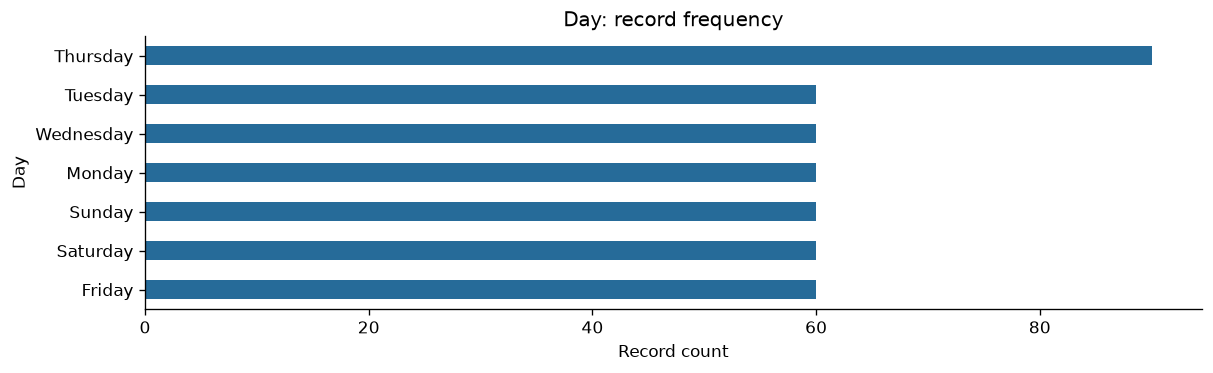

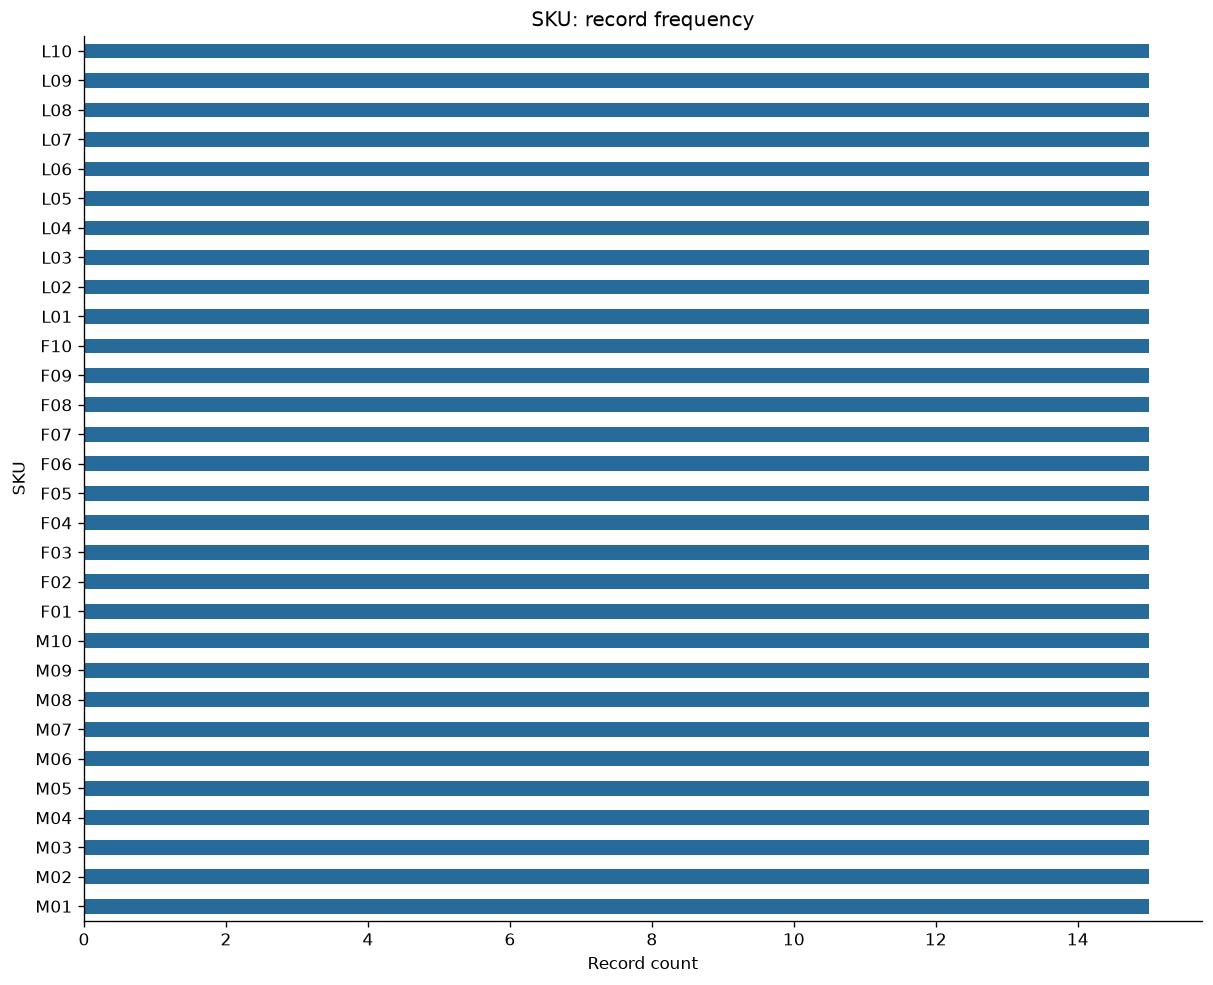

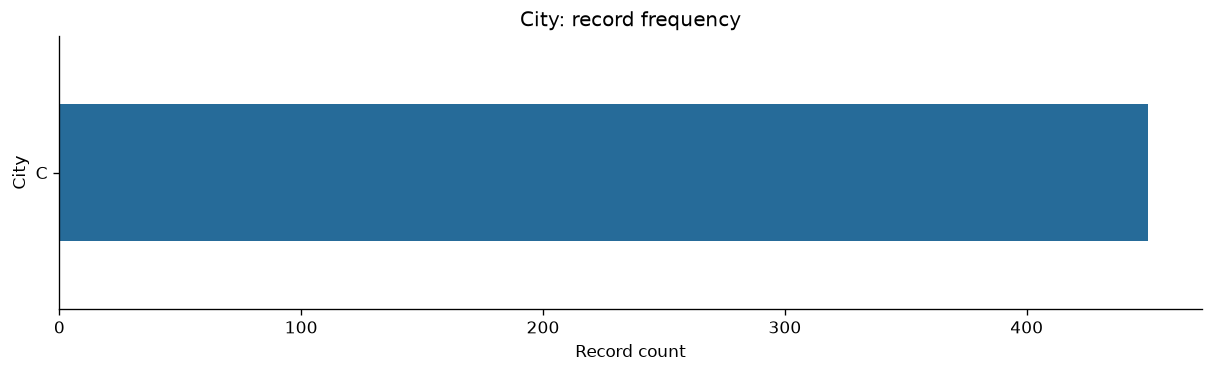

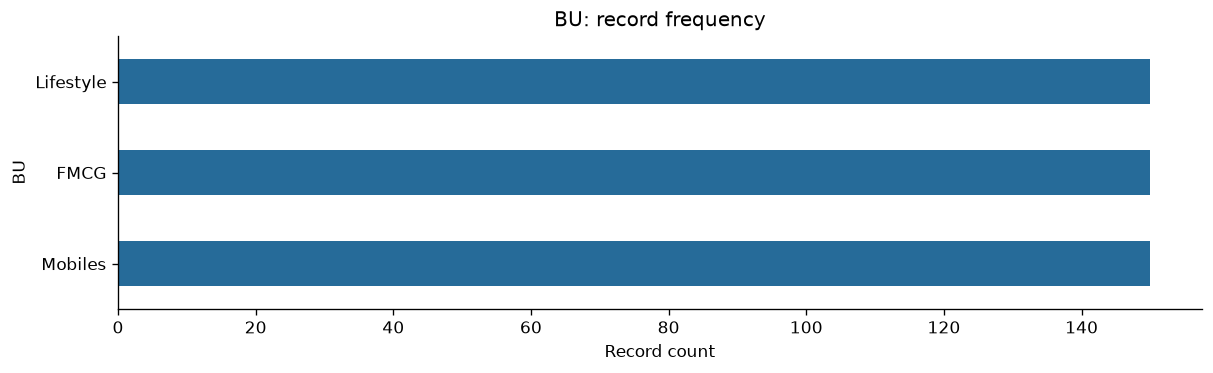

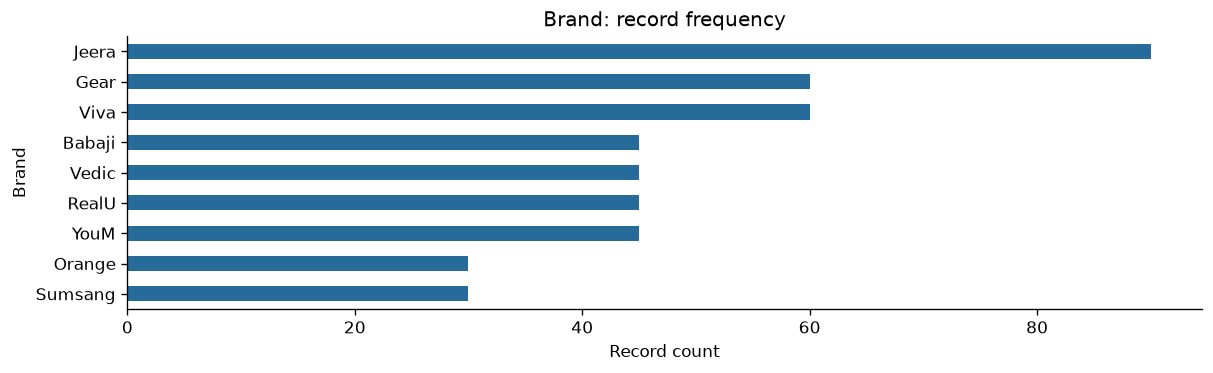

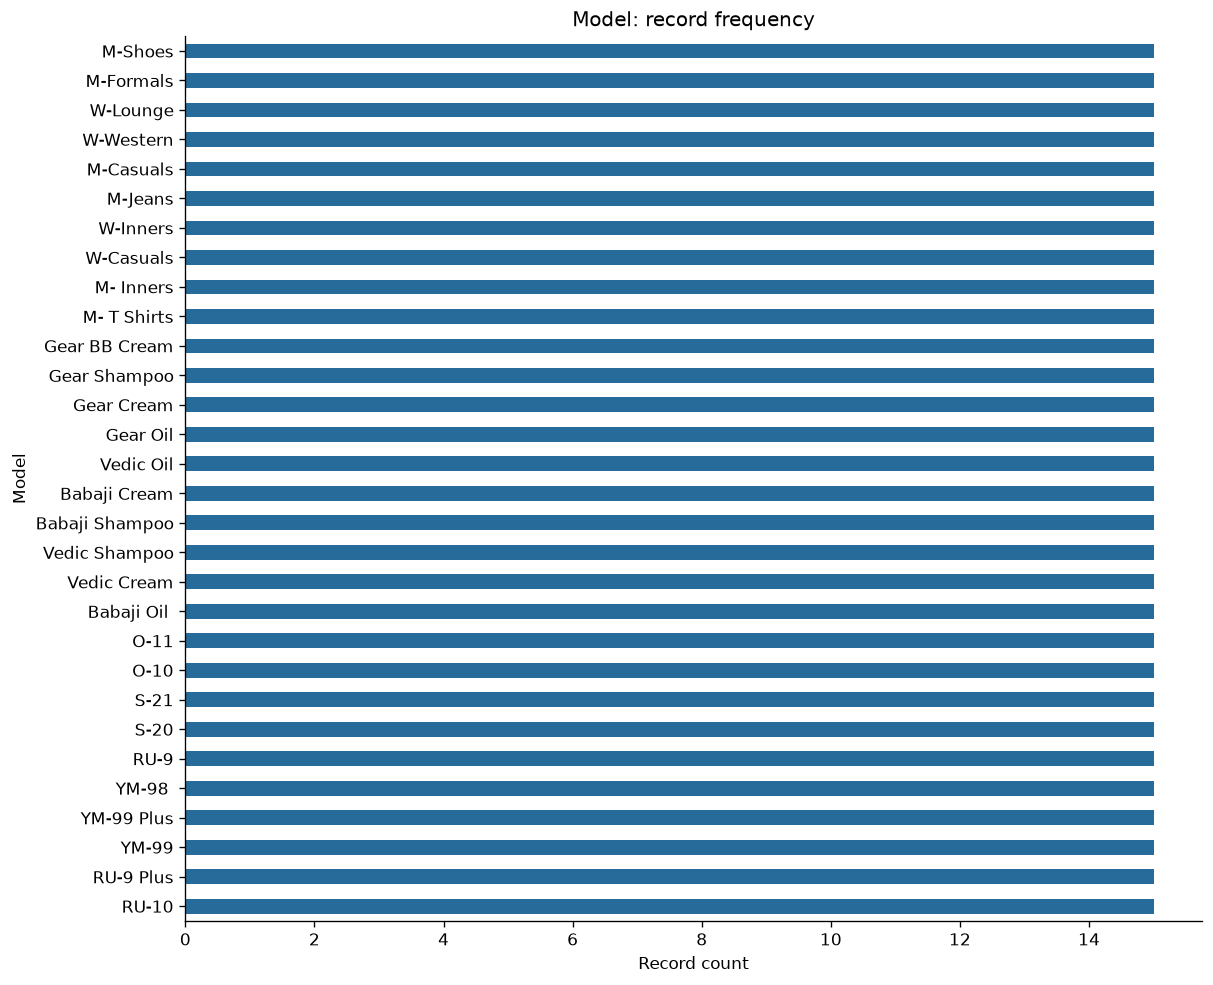

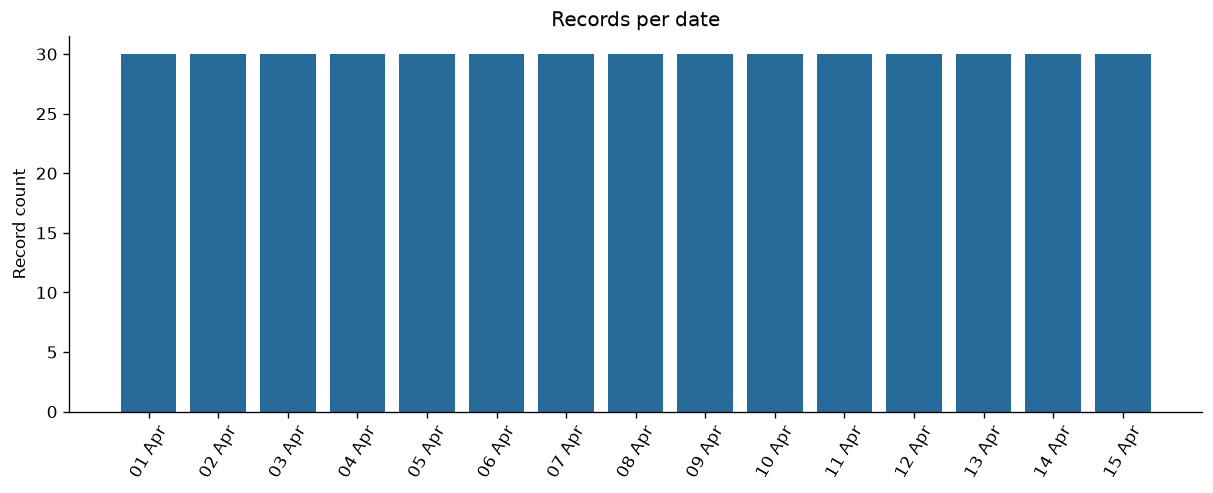

,records,units,net_sales
BU,,,
FMCG,150,929,3.276562e+05
Lifestyle,150,710,7.419696e+05
Mobiles,150,641,1.264023e+07


Brand counts:
Brand
Jeera      90
Gear       60
Viva       60
RealU      45
YouM       45
Babaji     45
Vedic      45
Sumsang    30
Orange     30


In [5]:
category_rows = []
for c in categorical:
    counts = df[c].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(10, max(3, len(counts)*.27)), constrained_layout=True)
    counts.plot.barh(ax=ax, color='#266b99')
    ax.set(title=f'{c}: record frequency', xlabel='Record count', ylabel=c)
    fig.savefig(BASE / 'figures' / f'category_{c.lower()}.png')
    plt.show()
    for value, count in counts.items():
        category_rows.append([c, value, count, count/len(df)])
pd.DataFrame(category_rows, columns=['variable','category','count','share']).to_csv(
    BASE/'results/category_frequencies.csv', index=False)
daily = df.groupby('Date').size()
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.bar(daily.index.strftime('%d %b'), daily.values, color='#266b99')
ax.tick_params(axis='x', rotation=60)
ax.set(title='Records per date', ylabel='Record count')
fig.savefig(BASE/'figures/date_coverage.png'); plt.show()
display(df.groupby('BU').agg(records=('SKU','size'), units=('Volume','sum'),
                             net_sales=('Net Sales Value','sum')))
print('Brand counts:'); print(df.Brand.value_counts().to_string())

### Interpretation
The dataset covers 15 consecutive dates with 30 records per date. Each of the three business units has 150 records; each SKU and Model occurs 15 times. City is constant (C), so it provides no discrimination in this sample. Jeera is the most frequent brand with 90 records (20%). Weekday counts reflect calendar coverage: Thursday has 90 records, while each other weekday has 60. Equal record counts do not imply equal sales or demand. The regular coverage suggests a structured sample whose representativeness of wider sales is unknown.

## 5. Standardize numerical variables
For each numerical column, **z = (x − μ) / σ**. Here μ and σ are the mean and population-convention standard deviation of the available dataset (**ddof=0**), matching common machine-learning scalers. This differs intentionally from the sample SD used in the descriptive table.

Standardization changes units and scale, but preserves shape, skewness, and relative positions. It does not make a skewed distribution normal or remove outliers. For predictive modeling, split the data first and estimate scaling parameters on the training set only.

,before_mean,before_std_ddof0,after_mean,after_std_ddof0
Volume,5.066667,4.226898,6.118562e-17,1.0
Avg Price,10453.433333,18059.804884,3.157968e-17,1.0
Total Sales Value,33812.835556,50478.892861,1.578984e-17,1.0
Discount Rate (%),15.155242,4.215910,-3.552714e-17,1.0
Discount Amount,3346.499424,4504.889173,-5.526444e-17,1.0
Net Sales Value,30466.336131,46307.118357,1.973730e-17,1.0


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,2.350029,0.091173,2.925721,-0.830289,3.952816,2.804756
1,1.167129,-0.019570,1.330995,-0.852661,1.849014,1.271026
2,0.457388,0.312659,1.562775,-1.351631,1.622995,1.545675
3,0.220808,0.534146,1.719276,-1.949723,1.113807,1.765810
4,-0.488932,-0.130313,-0.188452,0.673739,0.227852,-0.227595


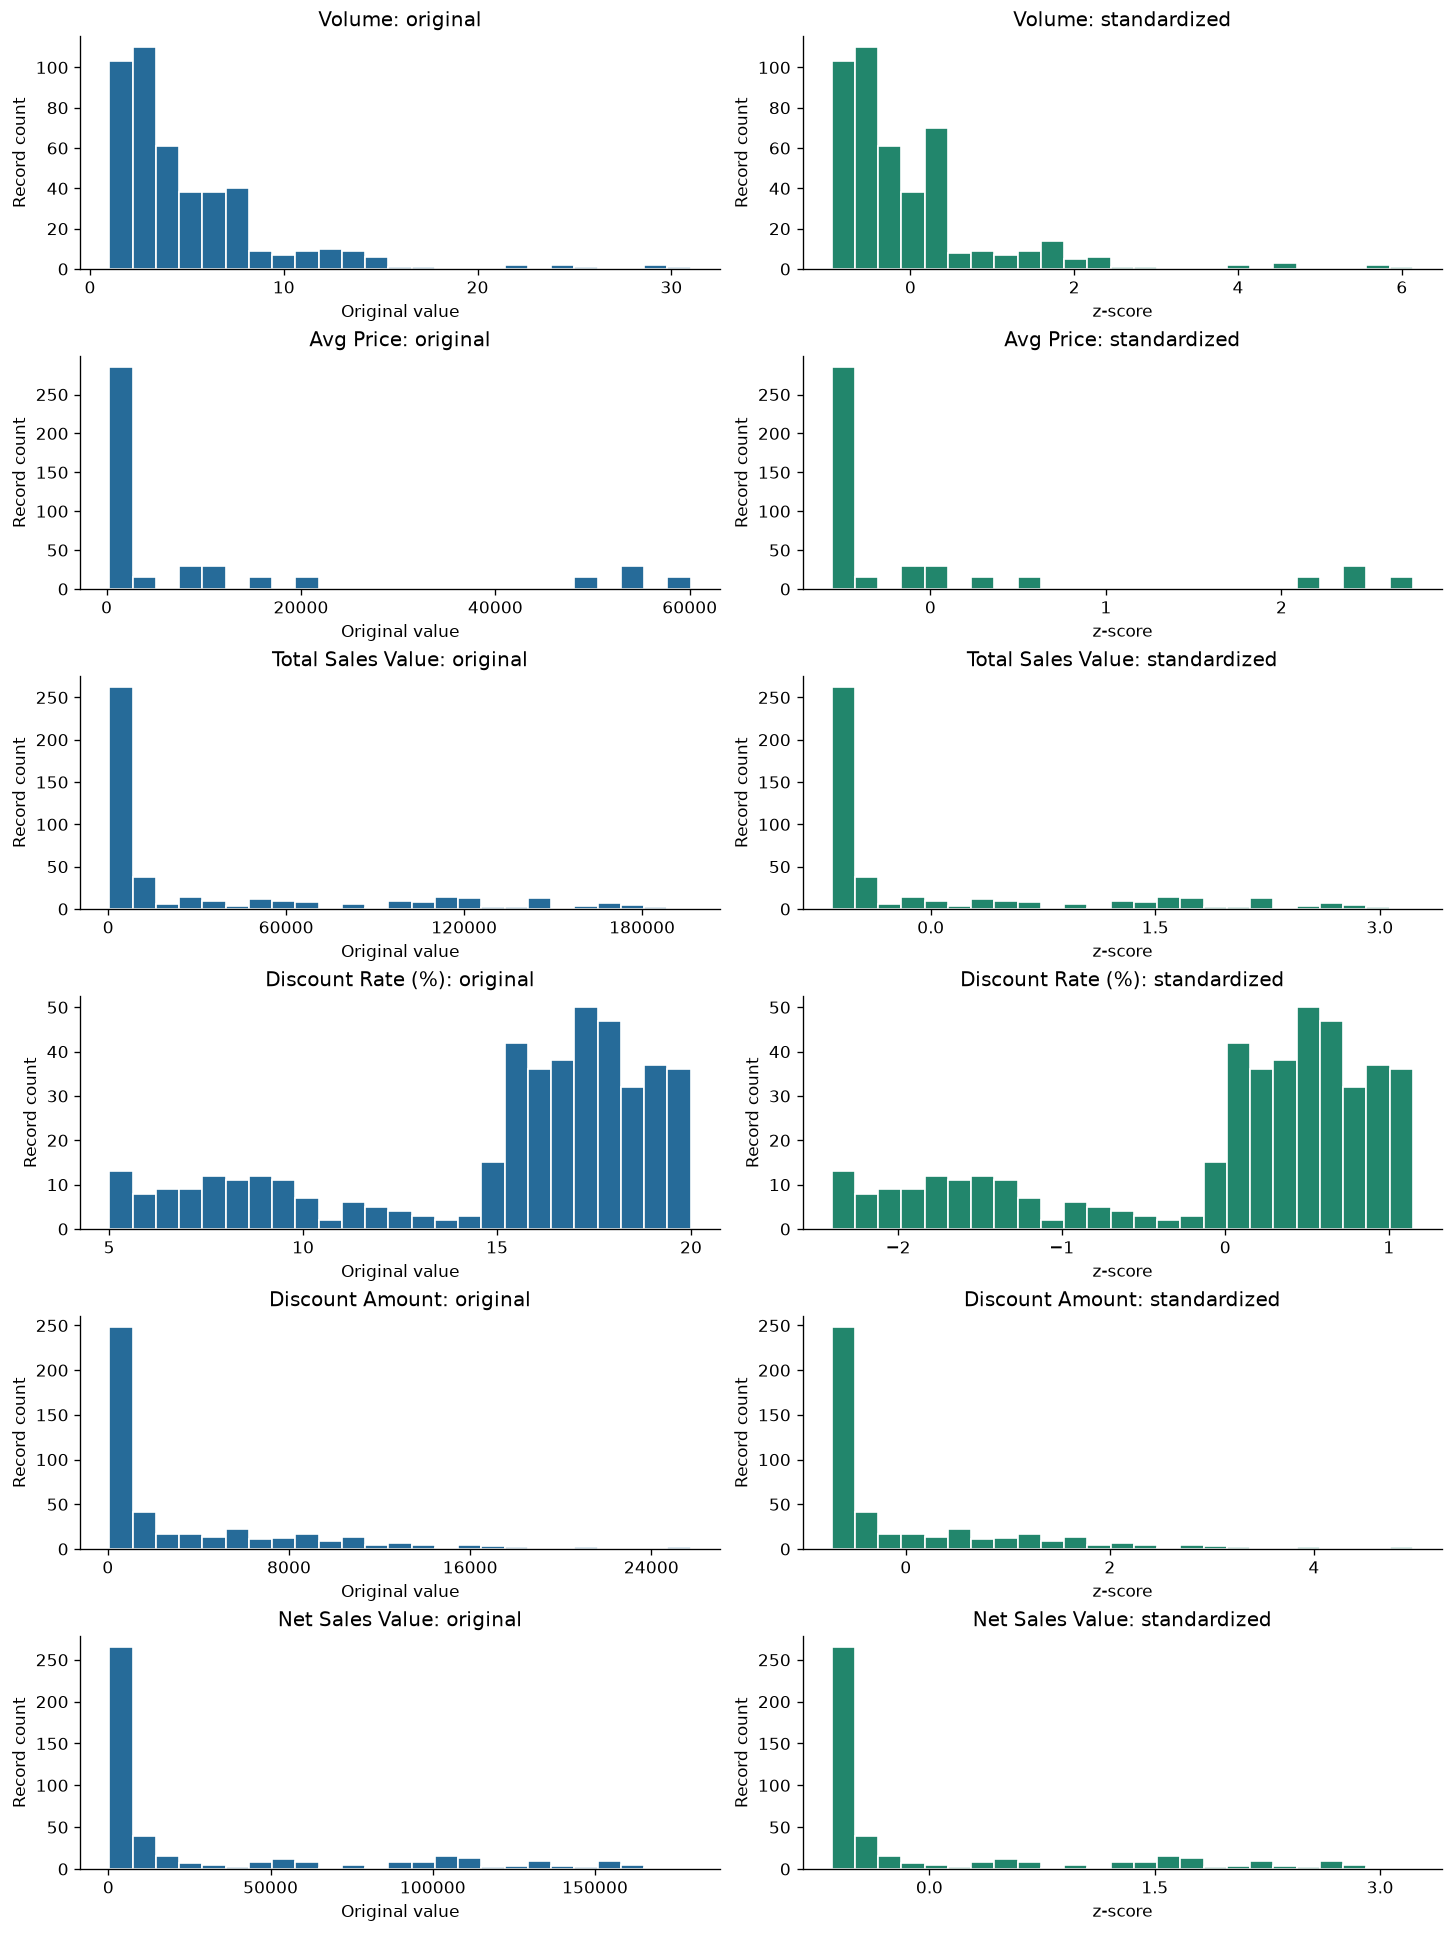

In [6]:
means = df[numeric].mean()
scales = df[numeric].std(ddof=0)
assert (scales > 0).all(), 'Constant numeric columns need separate handling.'
standardized = (df[numeric] - means) / scales
comparison = pd.DataFrame({'before_mean': means, 'before_std_ddof0': scales,
                          'after_mean': standardized.mean(),
                          'after_std_ddof0': standardized.std(ddof=0)})
display(comparison)
display(standardized.head())
assert np.allclose(standardized.mean(), 0, atol=1e-12)
assert np.allclose(standardized.std(ddof=0), 1, atol=1e-12)
standardized.to_csv(BASE/'results/standardized_numeric.csv', index=False)
comparison.to_csv(BASE/'results/scaling_parameters_and_checks.csv')
fig, axes = plt.subplots(len(numeric), 2, figsize=(12, 16), constrained_layout=True)
for row, c in enumerate(numeric):
    axes[row,0].hist(df[c], bins=25, color='#266b99', edgecolor='white')
    axes[row,0].set(title=f'{c}: original', ylabel='Record count', xlabel='Original value')
    axes[row,1].hist(standardized[c], bins=25, color='#22866c', edgecolor='white')
    axes[row,1].set(title=f'{c}: standardized', xlabel='z-score', ylabel='Record count')
    for ax in axes[row]:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
fig.savefig(BASE/'figures/before_after_standardization.png')
plt.show()

## 6. One-hot encode categorical variables
Nominal categories have no inherent numerical order. One-hot encoding creates a binary indicator for each category without imposing an artificial ranking. All levels are retained to show the full assignment transformation; a linear model with an intercept generally needs a reference level removed or another method to handle collinearity.

Date remains in the raw data and is excluded from the feature matrix. Real modeling would derive appropriate calendar features. City is constant and SKU and Model are redundant identifiers; all are included for this demonstration but should be reconsidered for a particular modeling goal.

In [7]:
dummies = pd.get_dummies(df[categorical], columns=categorical, dtype=int, drop_first=False)
assert set(np.unique(dummies.to_numpy())) <= {0, 1}
assert (dummies.sum(axis=1) == len(categorical)).all()
transformed = pd.concat([standardized, dummies], axis=1)
assert transformed.shape[0] == df.shape[0]
assert not transformed.isna().any().any()
print(f'{len(categorical)} categorical variables -> {dummies.shape[1]} binary columns')
print('Final feature matrix:', transformed.shape)
display(transformed.iloc[:5, :16])
transformed.to_csv(BASE/'results/preprocessed_features.csv', index=False)
mapping = {c: sorted(df[c].unique().tolist()) for c in categorical}
import json
(BASE/'results/category_levels.json').write_text(json.dumps(mapping, indent=2), encoding='utf-8')

6 categorical variables -> 80 binary columns
Final feature matrix: (450, 86)


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,SKU_F01,SKU_F02,SKU_F03
0,2.350029,0.091173,2.925721,-0.830289,3.952816,2.804756,0,0,0,0,1,0,0,0,0,0
1,1.167129,-0.019570,1.330995,-0.852661,1.849014,1.271026,0,0,0,0,1,0,0,0,0,0
2,0.457388,0.312659,1.562775,-1.351631,1.622995,1.545675,0,0,0,0,1,0,0,0,0,0
3,0.220808,0.534146,1.719276,-1.949723,1.113807,1.765810,0,0,0,0,1,0,0,0,0,0
4,-0.488932,-0.130313,-0.188452,0.673739,0.227852,-0.227595,0,0,0,0,1,0,0,0,0,0


1197

## 7. Conclusion
Most sales measures are strongly right-skewed, so median and IQR complement mean and standard deviation. The fixed date/product coverage and constant city limit generalization. Outlier flags are retained for investigation. Scaling places six numerical features on a comparable scale; one-hot encoding represents six categorical variables as 80 binary indicators, giving 86 numeric features.

These transformations demonstrate preprocessing, but they are not a ready-to-train prediction pipeline. A future model needs a defined target, an appropriate split (often time-based), and preprocessing fitted only on training data. Related accounting variables can leak a target: for example, total sales and discount amount determine net sales exactly. No causal or predictive claim is made here.

**Source:** supplied `Basic stats - 1.zip`, containing `Basic statistics.docx` and the original CSV. Assignment requirements are summarized here; the raw CSV is unchanged.